# 🧠 Análisis Exploratorio del Dataset: Stroke Prediction
**Objetivo:** Explorar los datos crudos, identificar inconsistencias ocultas (como los valores "Unknown" en el estado de tabaquismo) y definir un flujo de limpieza y transformación riguroso para predecir accidentes cerebrovasculares, que luego llevaremos a nuestro entorno local en VS Code para construir el pipeline [1, 2].

**Diccionario de Variables Clave:**
* `id`: Identificador único del paciente.
* `gender`: Género del paciente ("Male", "Female" u "Other").
* `age`: Edad del paciente.
* `hypertension`: ¿El paciente tiene hipertensión? (0 = no, 1 = sí).
* `heart_disease`: ¿El paciente tiene alguna enfermedad cardíaca? (0 = no, 1 = sí).
* `ever_married`: ¿El paciente se ha casado alguna vez? ("No" o "Yes").
* `work_type`: Tipo de empleo ("children", "Govt_jov", "Never_worked", "Private" o "Self-employed").
* `Residence_type`: Tipo de entorno de residencia ("Rural" o "Urban").
* `avg_glucose_level`: Nivel promedio de glucosa en la sangre.
* `bmi`: Índice de masa corporal (Body Mass Index).
* `smoking_status`: Condición de tabaquismo ("formerly smoked", "never smoked", "smokes" o "Unknown"*).
* `stroke`: **Variable Objetivo.** ¿El paciente tuvo un accidente cerebrovascular? (1 = sí, 0 = no).

El ataque ataque cerebrovascular (ACV), o ictus, es una emergencia médica que ocurre cuando el flujo sanguíneo al cerebro se detiene (isquémico) o un vaso sanguíneo se rompe (hemorrágico), matando células cerebrales por falta de oxígeno. según la Organización Mundial de la Salud (OMS), el ictus es *la segunda causa principal de muerte* a nivel mundial, responsable de aproximadamente el 11 % del total de fallecimientos.

Este conjunto de datos se utiliza para predecir la probabilidad de que un paciente sufra un accidente cerebrovascular, basándose en parámetros como el sexo, la edad, diversas enfermedades y el tabaquismo. Cada fila de los datos proporciona información relevante sobre el paciente.

---

## 1. Primer vistazo al DataSet.

Se realiza importación de dependencias.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Se trae el dataset en cuestión.

In [10]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargamos el dataset
df = pd.read_csv("../data/healthcare-dataset-stroke-data.csv")
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Estandarización de Nulos.

Antes de realizar el conteo total de valores faltantes, tales como 'Unknown' o 'NaN', es necesario aplicar una transformación que permita estandarizar dichos campos. Por ejemplo, si en una columna tenemos un valor oculto de tipo 'na' y en otra 'unknown' (en minúsculas), se debe conservar una única identificación para el valor nulo. Esto es crucial tanto para la precisión del análisis matemático como para su correcta exposición gráfica.

In [39]:
# 1. Definimos los valores basura
valores_basura = ['unknown', 'Unknown', 'UNKNOWN', 'na', 'NA']

Se reemplaza todo lo que pueda ser un valor faltante por un tipo de dato "NaN" de la libreria Numpy, lo cual se ajusta a un estandar para hacer este análisis exploratorio.

In [40]:
df = df.replace(valores_basura, np.nan)

In [ ]:
print("--- Conteo de 'NaN' por columna ---")
# Suma todos los NaN
count_nan = df.isnull().sum()

print(count_nan[count_nan > 0].sort_values(ascending=False))

--- Conteo de 'NaN' por columna ---
smoking_status    1544
bmi                201
dtype: int64


Se crea un mapa de calor para visualización de datos.

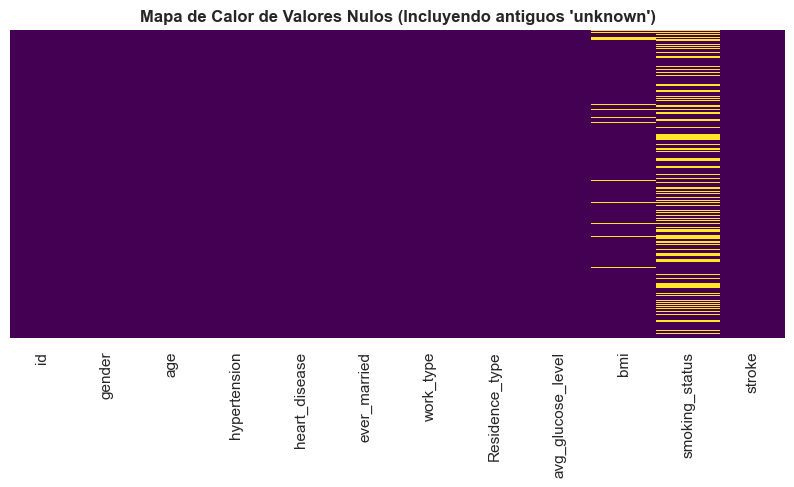

In [54]:
# Mapa de Calor Optimizado para valores nulos
plt.figure(figsize=(10, 4))

# Usamos df.isnull() para que evalúe si es True (nulo) o False (dato válido)
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)

plt.title("Mapa de Calor de Valores Nulos (Incluyendo antiguos 'unknown')", fontweight='bold')

# Guardar el gráfico
#plt.savefig('../outputs/graficos/null_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Variable Objetivo: `stroke`
**¿El paciente sufrió un ataque cerebrovascular?**

En nuestro conjunto de datos, la variable a predecir (target) es `stroke`. Es una variable de clasificación binaria que indica el historial médico del paciente respecto a esta afección:
* **`1`**: El paciente **sí** sufrió un ataque cerebrovascular.
* **`0`**: El paciente **no** sufrió un ataque cerebrovascular.

Realizaremos un gráfico que nos permitira analizar la proporción de esta variable.

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='y', palette='viridis')
plt.title('Distribución de la Variable Stroke (Ataque cerebrovascular)')
plt.ylabel('Cantidad de Pacientes')
plt.xlabel('Sufrió un ataque?')